# Unit 2: BoardShim 基础 —— 连接与数据流

## 学习目标
- 掌握 `BoardShim.get_board_descr()` 获取板卡信息
- 理解数据数组的行列结构（通道 × 采样点）
- 正确提取 EEG 通道、时间戳、Marker 通道
- 学习 `get_board_data()` 与 `get_current_board_data()` 的区别
- 使用 Synthetic Board 进行完整的数据获取练习

In [63]:
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from brainflow.board_shim import (
    BoardShim, 
    BrainFlowInputParams, 
    BoardIds, 
    BrainFlowPresets
)
from brainflow.data_filter import (
    DataFilter, 
    FilterTypes, 
    DetrendOperations
)

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print("模块导入完成")

模块导入完成


## 2.1 获取板卡描述信息

`BoardShim.get_board_descr(board_id)` 是最核心的元数据查询方法，
返回一个字典，包含该板卡的所有通道布局和参数信息。

In [3]:
# 查看 Synthetic Board 的完整描述
board_id = BoardIds.SYNTHETIC_BOARD
descr = BoardShim.get_board_descr(board_id)

print("=" * 60)
print(f"板卡名称: {descr.get('name', 'Unknown')}")
print(f"采样率: {descr.get('sampling_rate', 'N/A')} Hz")
print(f"总通道数 (num_rows): {descr.get('num_rows', 'N/A')}")
print("=" * 60)

# 通道索引信息
print(f"\n📌 EEG 通道索引:     {descr.get('eeg_channels', [])}")
print(f"📌 EEG 通道名称:     {descr.get('eeg_names', [])}")
print(f"📌 时间戳通道索引:   {descr.get('timestamp_channel', [])}")
print(f"📌 Marker 通道索引:  {descr.get('marker_channel', [])}")
print(f"📌 包序号通道索引:   {descr.get('package_num_channel', [])}")

# 可选通道（Synthetic Board 可能有 accel/gyro）
for key in ['accel_channels', 'gyro_channels', 'battery_channel', 'eda_channels']:
    val = descr.get(key)
    if val and (isinstance(val, list) and len(val) > 0 or isinstance(val, int)):
        print(f"📌 {key}: {val}")

板卡名称: Synthetic
采样率: 250 Hz
总通道数 (num_rows): 32

📌 EEG 通道索引:     [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
📌 EEG 通道名称:     Fz,C3,Cz,C4,Pz,PO7,Oz,PO8,F5,F7,F3,F1,F2,F4,F6,F8
📌 时间戳通道索引:   30
📌 Marker 通道索引:  31
📌 包序号通道索引:   0
📌 accel_channels: [17, 18, 19]
📌 gyro_channels: [20, 21, 22]
📌 battery_channel: 29
📌 eda_channels: [23]


d:\AI\trae_solo\Brain\openbci-5\.venv\lib\site-packages\brainflow\board_shim.py:185: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


### 对比不同板卡的描述信息

BrainFlow 的统一抽象意味着只需要更改 `board_id`，就能看到不同硬件的通道布局。

In [17]:
# 对比不同板卡的 EEG 通道配置
boards_to_compare = [
    ("Synthetic Board", BoardIds.SYNTHETIC_BOARD),
    ("Cyton (8ch)", BoardIds.CYTON_BOARD),
    ("Cyton+Daisy (16ch)", BoardIds.CYTON_DAISY_BOARD),
]

print(f"{'板卡':<25} {'通道数':<8} {'采样率':<8} {'EEG通道名'}")
print("-" * 80)
for name, bid in boards_to_compare:
    d = BoardShim.get_board_descr(bid)
    n_channels = len(d.get('eeg_channels', []))
    sr = d.get('sampling_rate', 'N/A')
    
    names_raw = d.get('eeg_names', [])
    # 如果是字符串，用逗号拆分；如果是列表，直接用
    if isinstance(names_raw, str):
        names = [n.strip() for n in names_raw.split(',')]
    else:
        names = names_raw
    
    print(f"{name:<25} {n_channels:<8} {str(sr) + ' Hz':<8} {names}")


板卡                        通道数      采样率      EEG通道名
--------------------------------------------------------------------------------
Synthetic Board           16       250 Hz   ['Fz', 'C3', 'Cz', 'C4', 'Pz', 'PO7', 'Oz', 'PO8', 'F5', 'F7', 'F3', 'F1', 'F2', 'F4', 'F6', 'F8']
Cyton (8ch)               8        250 Hz   ['Fp1', 'Fp2', 'C3', 'C4', 'P7', 'P8', 'O1', 'O2']
Cyton+Daisy (16ch)        16       125 Hz   ['Fp1', 'Fp2', 'C3', 'C4', 'P7', 'P8', 'O1', 'O2', 'F7', 'F8', 'F3', 'F4', 'T7', 'T8', 'P3', 'P4']


## 2.2 数据数组结构详解

`get_board_data()` 返回的数据是 **(num_rows, num_samples)** 的 2D 数组：

```text
Row 0:  包序号 (Package Num)
Row 1-8: EEG 通道 1-8  (EEG data in μV)
Row ... : 其他通道（如有）
Row N-2: 时间戳 (Timestamp, UNIX μs)
Row N-1: Marker 通道 (事件标记)
```

现在我们来实际操作：采集数据并正确分离各个通道。

In [ ]:
# 采集一段数据
params = BrainFlowInputParams()
board = BoardShim(BoardIds.SYNTHETIC_BOARD, params)
board.prepare_session()
board.start_stream()
time.sleep(5)
data = board.get_board_data()
board.stop_stream()
board.release_session()

# 获取板卡描述
descr = BoardShim.get_board_descr(BoardIds.SYNTHETIC_BOARD)

# 正确分离各通道
eeg_channels = descr['eeg_channels']
eeg_names = BoardShim.get_eeg_names(BoardIds.SYNTHETIC_BOARD)
ts_channel = descr['timestamp_channel']
marker_channel = descr['marker_channel']

print(f"EEG 通道: {eeg_channels}")
print(f"EEG 通道名: {eeg_names}")
print(f"时间戳通道: {ts_channel}")
print(f"标记通道: {marker_channel}")

eeg_data = data[eeg_channels, :]     # (8, N) — 仅 EEG 通道
timestamps = data[ts_channel, :]     # (N,)  — 时间戳
markers = data[marker_channel, :]    # (N,)  — 事件标记

print(f"原始数据形状: {data.shape}")
print(f"EEG 数据形状:  {eeg_data.shape}")
print(f"时间戳形状:    {timestamps.shape}")
print(f"\n时间戳范围: {timestamps[0]:.0f} → {timestamps[-1]:.0f}")
# 微秒(µs)或 (s) 板卡相关
print(f"采集时长:     {(timestamps[-1] - timestamps[0])} 秒")
print(f"\n各通道数据范围 (μV):")
for i, name in enumerate(eeg_names):
    print(f"  {name}: [{eeg_data[i].min():.1f}, {eeg_data[i].max():.1f}]")

EEG 通道: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
EEG 通道名: ['Fz', 'C3', 'Cz', 'C4', 'Pz', 'PO7', 'Oz', 'PO8', 'F5', 'F7', 'F3', 'F1', 'F2', 'F4', 'F6', 'F8']
时间戳通道: 30
标记通道: 31
原始数据形状: (32, 1253)
EEG 数据形状:  (16, 1253)
时间戳形状:    (1253,)

时间戳范围: 1778779538 → 1778779543
采集时长:     5.011224031448364 秒

各通道数据范围 (μV):
  Fz: [-4.8, 24.8]
  C3: [-10.9, 51.1]
  Cz: [-18.6, 78.6]
  C4: [-27.5, 107.5]
  Pz: [-37.7, 137.6]
  PO7: [-49.9, 169.9]
  Oz: [-76.8, 388.3]
  PO8: [-96.2, 446.1]
  F5: [-119.8, 494.4]
  F7: [-115.5, 567.8]
  F3: [-173.4, 643.6]
  F1: [-197.0, 705.5]
  F2: [-222.9, 765.2]
  F4: [-251.6, 791.6]
  F6: [-261.4, 866.3]
  F8: [-303.5, 991.7]


## 2.3 数据可视化

使用 matplotlib 将 EEG 信号绘制出来，观察 Synthetic Board 生成的模拟信号。

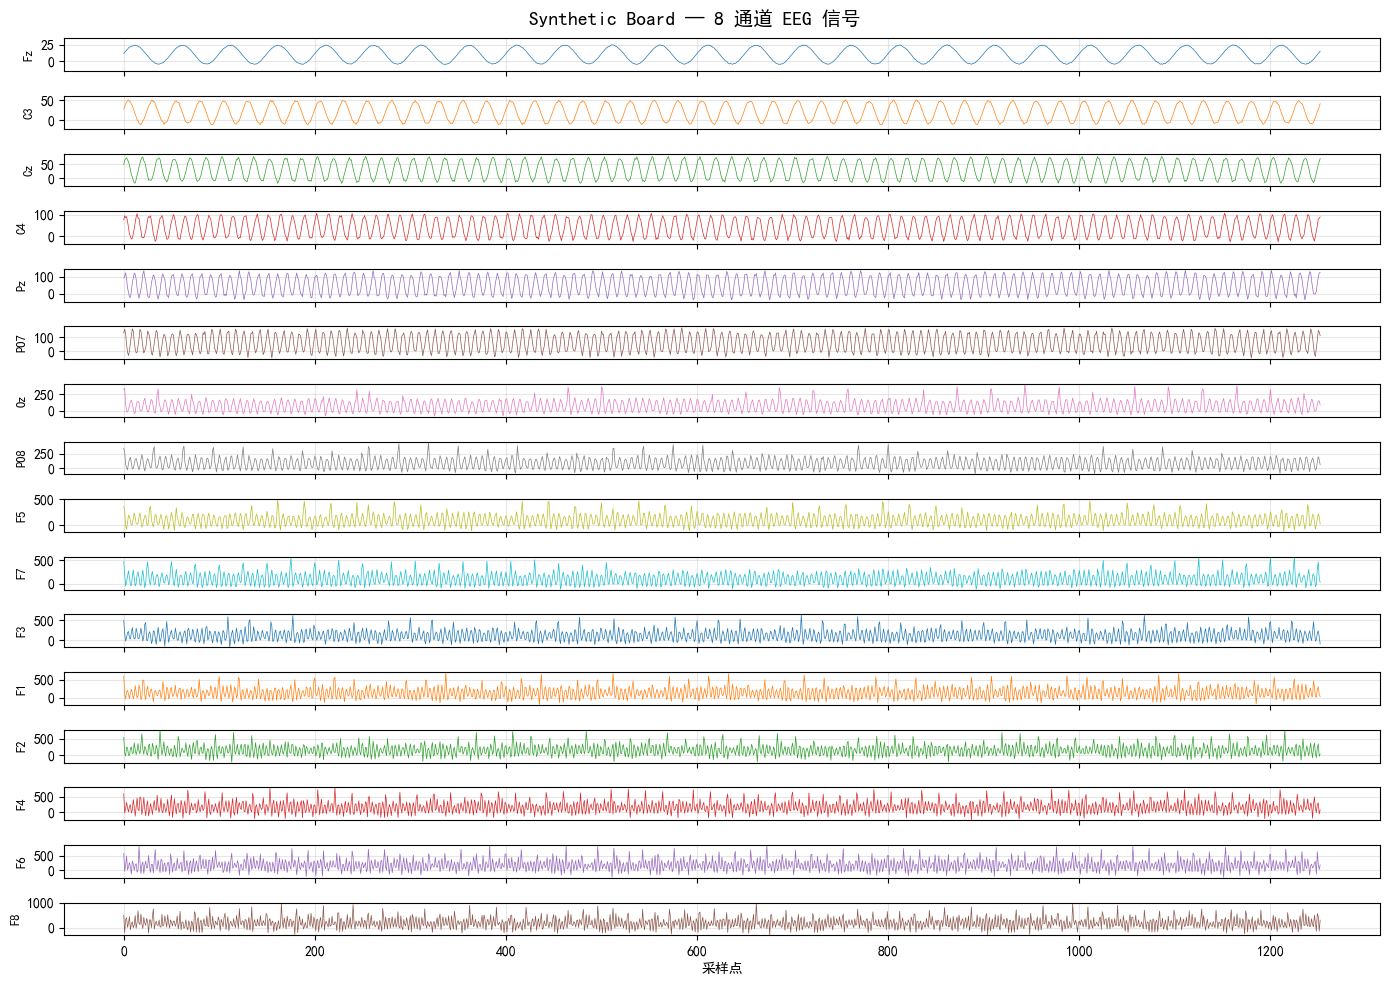

In [27]:
# 绘制所有 EEG 通道
fig, axes = plt.subplots(len(eeg_channels), 1, figsize=(14, 10), sharex=True)

for i, ax in enumerate(axes):
    ax.plot(eeg_data[i, :], linewidth=0.5, color=f'C{i}')
    ax.set_ylabel(f'{eeg_names[i]}', fontsize=9)
    ax.set_ylim(eeg_data[i].min() - 10, eeg_data[i].max() + 10)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('采样点')
fig.suptitle('Synthetic Board — 8 通道 EEG 信号', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# 使用 pandas 展示数据表格
df = pd.DataFrame(np.transpose(data))
# 转置为 df(采样点数, 通道数) 
# 重命名列
col_names = []
for i in range(data.shape[0]):
    if i in eeg_channels:
        idx = eeg_channels.index(i)
        col_names.append(eeg_names[idx])
    elif i == ts_channel:
        col_names.append('Timestamp')
    elif i == marker_channel:
        col_names.append('Marker')
    else:
        col_names.append(f'Ch_{i}')
df.columns = col_names

print("数据预览 (前10行):")
display(df.head(10))
print(f"\n数据统计:")
# 显示 EEG 通道数据的统计描述信息（计数、均值、标准差、最小值、四分位数、最大值）
display(df[eeg_names].describe())

数据预览 (前10行):


,Ch_0,Fz,C3,Cz,C4,Pz,PO7,Oz,PO8,F5,...,Ch_22,Ch_23,Ch_24,Ch_25,Ch_26,Ch_27,Ch_28,Ch_29,Timestamp,Marker
0,0.0,11.855007,28.427003,49.471509,76.384546,92.168427,133.395265,318.242882,341.823488,370.412337,...,0.843867,0.907202,473.844266,264640.661242,36.591250,948.597233,961.794772,84.877040,1.778780e+09,0.0
1,1.0,13.358489,33.737002,64.080014,94.855662,103.666082,160.378768,330.734813,272.274173,277.069727,...,0.926672,0.929837,506.363467,248780.887769,36.603815,1033.744968,952.909343,92.169680,1.778780e+09,0.0
2,2.0,15.144666,42.089719,69.865736,86.961579,123.607674,122.782664,96.282683,62.741496,-14.847315,...,0.987633,1.077145,463.590619,232850.139755,36.603398,937.170726,986.263677,85.325532,1.778780e+09,0.0
3,3.0,16.867153,45.340452,72.863776,91.779945,85.351218,46.333728,-1.727277,10.956497,-80.877232,...,0.807044,1.002894,518.122583,274910.949224,36.606143,989.694980,986.862039,87.223008,1.778780e+09,0.0
4,4.0,18.342815,50.031248,65.084992,68.557008,34.372713,-9.308608,-16.115891,-27.669271,62.675905,...,0.962358,0.936263,497.771607,274021.987748,36.608160,1070.559813,917.734022,93.433722,1.778780e+09,0.0
5,5.0,20.131641,50.840819,60.059939,38.810535,6.553090,-33.357837,18.202435,86.975383,196.501401,...,0.858226,0.959521,533.752636,242881.674429,36.592484,1011.328921,1028.927133,87.600221,1.778780e+09,0.0
6,6.0,21.259181,46.318882,45.225557,9.955715,-21.757685,0.290005,85.520483,147.915045,172.693732,...,0.834794,1.077967,479.853164,251292.778615,36.600176,1008.708141,1015.415238,81.530179,1.778780e+09,0.0
7,7.0,21.955489,46.620411,31.166440,-2.578445,-22.985262,59.911230,137.221505,188.831807,87.603907,...,0.819111,1.050680,544.713157,253809.157673,36.609462,905.473277,1084.400250,95.904212,1.778780e+09,0.0
8,8.0,22.188551,39.808287,13.516571,-14.805913,15.092217,110.171282,160.605083,82.253436,2.010200,...,0.929469,1.000172,514.908873,246452.001770,36.605310,963.156209,918.378869,84.407555,1.778780e+09,0.0
9,9.0,23.159767,36.612002,4.608182,-9.231676,63.732766,162.462807,103.754188,-13.948733,18.338624,...,0.959712,1.048832,515.051335,260565.986618,36.605287,1009.238127,928.958509,97.693085,1.778780e+09,0.0



数据统计:


,Fz,C3,Cz,C4,Pz,PO7,Oz,PO8,F5,F7,F3,F1,F2,F4,F6,F8
count,1253.000000,1253.000000,1253.000000,1253.000000,1253.000000,1253.000000,1253.000000,1253.000000,1253.000000,1253.000000,1253.000000,1253.000000,1253.000000,1253.000000,1253.000000,1253.000000
mean,10.006821,20.041691,30.118950,40.239702,49.994513,60.704567,76.348285,87.000925,101.755497,111.533236,125.799496,139.540299,150.771284,164.775945,178.185139,190.222417
std,10.016939,20.066802,30.016038,40.300834,50.565425,60.603639,83.324152,94.542752,111.460981,126.534019,139.931759,155.906335,167.900751,192.272486,204.425465,223.064563
min,-4.806654,-10.868473,-18.560010,-27.456203,-37.668139,-49.889943,-76.837370,-96.227330,-119.781974,-115.458711,-173.438721,-196.981848,-222.915989,-251.570956,-261.372812,-303.462872
25%,0.107504,0.917491,0.537133,0.510963,0.660974,3.718216,3.198698,7.551654,13.824882,-2.748045,19.309150,19.370187,32.941813,24.673054,29.890837,29.501710
50%,10.000000,21.440195,30.944470,38.625371,60.617311,59.882100,75.243673,83.691310,93.372553,127.098613,115.730591,128.567085,139.867038,151.896994,161.667269,175.255466
75%,19.862831,40.155062,59.523884,79.707865,99.525666,118.887361,139.894981,158.306336,181.179746,184.840839,212.891866,241.693024,254.648551,280.386940,299.815562,323.113639
max,24.808658,51.108234,78.585003,107.505735,137.607966,169.932723,388.303652,446.128356,494.423505,567.792997,643.579631,705.509860,765.213615,791.621219,866.263996,991.678009


## 2.4 get_board_data() vs get_current_board_data()

这两个方法的关键区别：

| 方法 | 清空缓冲区 | 用途 |
|------|------------|------|
| `get_board_data()` | ✅ 是 | 一次性获取所有数据，处理后清空 |
| `get_current_board_data(n)` | ❌ 否 | 获取最新 n 个样本，保留缓冲区，适合实时处理 |

In [38]:
# 演示 get_current_board_data —— 不消耗缓冲区
board = BoardShim(BoardIds.SYNTHETIC_BOARD, BrainFlowInputParams())
board.prepare_session()
board.start_stream()
time.sleep(2)

# 获取最新 50 个样本（不清空缓冲区）
data_chunk1 = board.get_current_board_data(50)
print(f"第一次获取后缓冲区样本数: {board.get_board_data_count()}")

# 再次获取（缓冲区仍保留）
data_chunk2 = board.get_current_board_data(50)
print(f"第二次获取后缓冲区样本数: {board.get_board_data_count()}")

time.sleep(0.5)
# 使用 get_board_data 清空缓冲区
all_data = board.get_board_data()
print(f"get_board_data() 后缓冲区样本数: {board.get_board_data_count()}")

board.stop_stream()
board.release_session()

print(f"\nchunk1 形状: {data_chunk1.shape}")
print(f"chunk2 形状: {data_chunk2.shape}")
print(f"all_data 形状: {all_data.shape}")

第一次获取后缓冲区样本数: 503
第二次获取后缓冲区样本数: 503
get_board_data() 后缓冲区样本数: 0

chunk1 形状: (32, 50)
chunk2 形状: (32, 50)
all_data 形状: (32, 631)


## 2.5 便捷类方法

BrainFlow 提供了多个类方法来快速获取板卡信息，无需先获取完整 descr：

In [ ]:
board_id = BoardIds.SYNTHETIC_BOARD

# 类方法 —— 无需实例化即可调用
print(f"采样率:       {BoardShim.get_sampling_rate(board_id)} Hz")
print(f"EEG 通道:     {BoardShim.get_eeg_channels(board_id)}")
print(f"EEG 通道名:   {BoardShim.get_eeg_names(board_id)}")
print(f"时间戳通道:   {BoardShim.get_timestamp_channel(board_id)}")
print(f"Marker 通道:  {BoardShim.get_marker_channel(board_id)}")
print(f"包序号通道:   {BoardShim.get_package_num_channel(board_id)}")
print(f"板卡预设:     {BoardShim.get_board_presets(board_id)}")

# 所有 EXG 通道（EEG + EMG + ECG）
# EXG 通道本质上是脑电、肌电、心电、眼电等生物电信号的统一采集通道，具体采集哪类信号取决于电极放置位置和实验设计。
try:
    print(f"EXG 通道:     {BoardShim.get_exg_channels(board_id)}")
except Exception as e:
    print(f"EXG 通道:     不支持 ({e})")

采样率:       250 Hz
EEG 通道:     [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
EEG 通道名:   ['Fz', 'C3', 'Cz', 'C4', 'Pz', 'PO7', 'Oz', 'PO8', 'F5', 'F7', 'F3', 'F1', 'F2', 'F4', 'F6', 'F8']
时间戳通道:   30
Marker 通道:  31
包序号通道:   0
板卡预设:     [1, 0]
EXG 通道:     [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]


## 2.6 Session 生命周期异常处理

在实际开发中，应当确保即使发生异常也能正确释放资源。

In [91]:
import time
import numpy as np
from brainflow.board_shim import BoardShim, BoardIds, BrainFlowInputParams

def safe_session_demo():
    """演示带异常处理的会话管理"""
    board = None
    try:
        board = BoardShim(BoardIds.SYNTHETIC_BOARD, BrainFlowInputParams())
        board.prepare_session()
        board.start_stream()
        time.sleep(1)
        data = board.get_board_data()
        print(f"✅ 成功采集 {data.shape[1]} 个样本")
        return data
    except Exception as e:
        print(f"❌ 错误: {e}")
    finally:
        if board is not None:
            try:
                if board.is_prepared():
                    board.stop_stream()
                    board.release_session()
                    print("🔒 资源已安全释放")
            except Exception:
                pass

_ = safe_session_demo()

✅ 成功采集 251 个样本
🔒 资源已安全释放


自己封装一个上下文管理器，用于自动准备会话、启动流、获取数据、停止流、释放会话。  
!!! warning
    这个方式会报错

In [53]:
import time
import numpy as np
from brainflow.board_shim import BoardShim, BoardIds, BrainFlowInputParams

class BoardContext:
    def __init__(self, board_id=BoardIds.SYNTHETIC_BOARD, params=None):
        self.board_id = board_id
        self.params = params or BrainFlowInputParams()
        self.board = None

    def __enter__(self):
        self.board = BoardShim(self.board_id, self.params)
        self.board.prepare_session()
        print("会话已准备")
        self.board.start_stream()
        print("数据流已启动")
        return self.board

    def __exit__(self, exc_type, exc_val, exc_tb):
            try:
                if self.board is not None:
                    self.board.stop_stream()
                    print("数据流已停止")
                    self.board.release_session()
                    print("会话已释放")
            except Exception as e:
                print(f"退出时发生异常: {e}")

# 使用示例
with BoardContext() as board:
    time.sleep(1)
    data = board.get_board_data()
    print(f"采集到 {data.shape} 个样本")

会话已准备
数据流已启动
采集到 (32, 253) 个样本
数据流已停止
会话已释放


## 2.7 小练习

用 Synthetic Board 采集 10 秒数据，并完成以下任务：
1. 打印采集到的总样本数
2. 计算理论样本数（采样率 × 时间），与实际的比率
3. 绘制 Fz 和 Cz 两个通道的对比图
4. 计算 Fz 通道数据的均值和标准差

实际采集样本数: 2500
理论样本数:     2500
比率:           100.00%


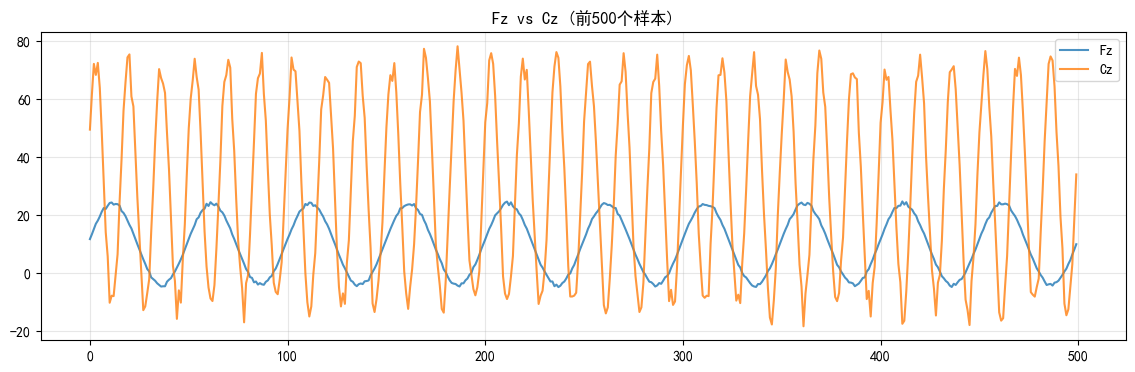


Fz 通道统计: 均值=10.00 μV, 标准差=10.00 μV


In [64]:
# === 你的练习代码 ===

board = BoardShim(BoardIds.SYNTHETIC_BOARD, BrainFlowInputParams())
board.prepare_session()
board.start_stream()
time.sleep(10)
data = board.get_board_data()
board.stop_stream()
board.release_session()

descr = BoardShim.get_board_descr(BoardIds.SYNTHETIC_BOARD)
eeg_channels = descr['eeg_channels']
eeg_names = BoardShim.get_eeg_names(BoardIds.SYNTHETIC_BOARD)
sampling_rate = descr['sampling_rate']

# 1. 总样本数
n_samples = data.shape[1]
print(f"实际采集样本数: {n_samples}")

# 2. 理论样本数
theoretical = sampling_rate * 10
print(f"理论样本数:     {theoretical}")
print(f"比率:           {n_samples / theoretical:.2%}")

# 3. Fz vs Cz 对比图
fz_idx = eeg_names.index('Fz')
cz_idx = eeg_names.index('Cz')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(data[eeg_channels[fz_idx], :500], label='Fz', alpha=0.8)
ax.plot(data[eeg_channels[cz_idx], :500], label='Cz', alpha=0.8)
ax.legend()
ax.set_title('Fz vs Cz (前500个样本)')
ax.grid(True, alpha=0.3)
plt.show()

# 4. Fz 均值与标准差
fz_data = data[eeg_channels[fz_idx], :]
print(f"\nFz 通道统计: 均值={fz_data.mean():.2f} μV, 标准差={fz_data.std():.2f} μV")

## 小结

| 知识点 | 要点 |
|--------|------|
| `get_board_descr()` | 获取板卡完整元数据（通道布局、采样率等） |
| 数据数组 | (num_rows, num_samples)，用通道索引提取 |
| `get_board_data()` | 获取全部数据，清空缓冲区 |
| `get_current_board_data(n)` | 获取最新 n 样本，不清空缓冲区 |
| 类方法 | `get_eeg_channels()`, `get_sampling_rate()` 等 |
| 异常安全 | 使用 try/finally 确保释放资源 |

→ [Unit 3: 数据采集深入](unit3_data_acquisition.ipynb) — 学习不同板卡类型、CSV回放、流式传输